In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE = "../data/raw/AAPL_1h.csv"
df = pd.read_csv(FILE, header=[0,1], index_col=0)

# Convert index to datetime
df.index = pd.to_datetime(df.index)

# Flatten multi-level columns
df.columns = df.columns.get_level_values(0)
df = df.sort_index()

# Target variable (next close)
df["target"] = df["Close"].shift(-1)

print(df.shape)
df.head()

(415, 7)


Datetime,Adj Close,Close,High,Low,Open,Volume,target
2025-12-04 15:30:00+00:00,280.279999,280.279999,281.600006,279.809998,281.209991,2986361,280.114990
2025-12-04 16:30:00+00:00,280.114990,280.114990,280.933502,279.937805,280.285004,2285394,280.005005
2025-12-04 17:30:00+00:00,280.005005,280.005005,280.486694,279.640015,280.130005,1806229,278.859985
2025-12-04 18:30:00+00:00,278.859985,278.859985,280.100006,278.589996,279.989990,2574486,280.125000
2025-12-04 19:30:00+00:00,280.125000,280.125000,280.730011,278.820007,278.859985,2807996,280.649994


In [230]:
df[["Close", "target"]].head()


Datetime,Close,target
2025-12-04 15:30:00+00:00,280.279999,280.114990
2025-12-04 16:30:00+00:00,280.114990,280.005005
2025-12-04 17:30:00+00:00,280.005005,278.859985
2025-12-04 18:30:00+00:00,278.859985,280.125000
2025-12-04 19:30:00+00:00,280.125000,280.649994


# Check for mising values 

In [231]:
missing_values = df.isnull().sum()
print(missing_values)

Datetime
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
target       1
dtype: int64


# Visualize missing values using Bar Plot & Heat maps

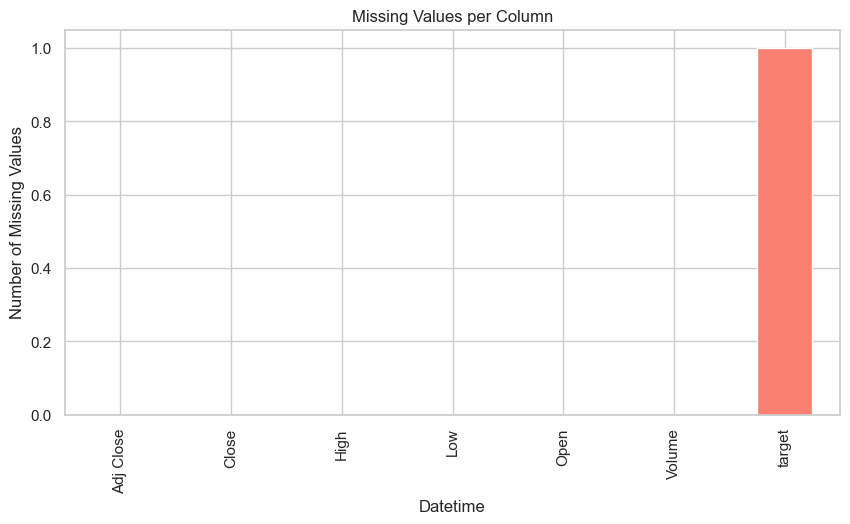

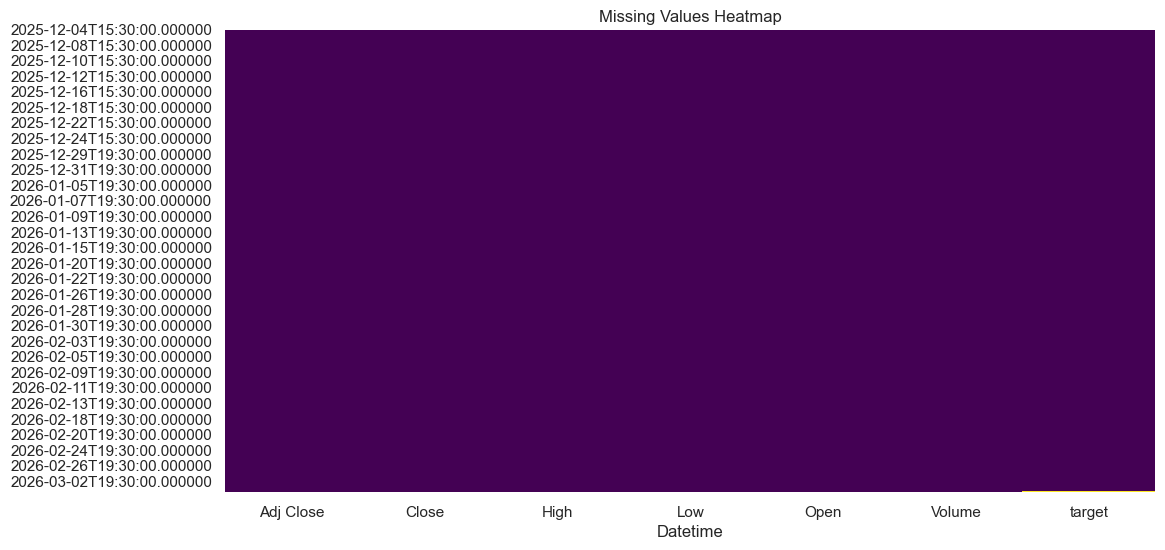

In [232]:
sns.set(style="whitegrid")


# Bar plot of missing values
plt.figure(figsize=(10,5))
missing_values.plot(kind='bar', color='salmon')
plt.title("Missing Values per Column")
plt.ylabel("Number of Missing Values")
plt.show()

# Heatmap of missing data
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# Check for outliers using Turkey's methode

In [233]:
cols = ["Adj Close", "Close", "High", "Low", "Open", "Volume", "target"]


df_check = df[cols].apply(pd.to_numeric, errors='coerce')

results = []

for col in cols:
    Q1 = df_check[col].quantile(0.25)
    Q3 = df_check[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_check[
        (df_check[col] < lower_bound) |
        (df_check[col] > upper_bound)
    ]

    results.append({
        "Column": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": round(len(outliers) / len(df_check) * 100, 2)
    })

# Create clean summary DataFrame
outlier_summary_df = pd.DataFrame(results)

outlier_summary_df

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Adj Close,2.391606e+02,2.948391e+02,0,0.00
1,Close,2.391606e+02,2.948391e+02,0,0.00
2,High,2.407725e+02,2.950325e+02,0,0.00
3,Low,2.379800e+02,2.943000e+02,0,0.00
4,Open,2.389500e+02,2.949900e+02,0,0.00
5,Volume,-1.006864e+06,7.049924e+06,50,12.05
6,target,2.391254e+02,2.948311e+02,0,0.00


# Visualize features using boxplots 

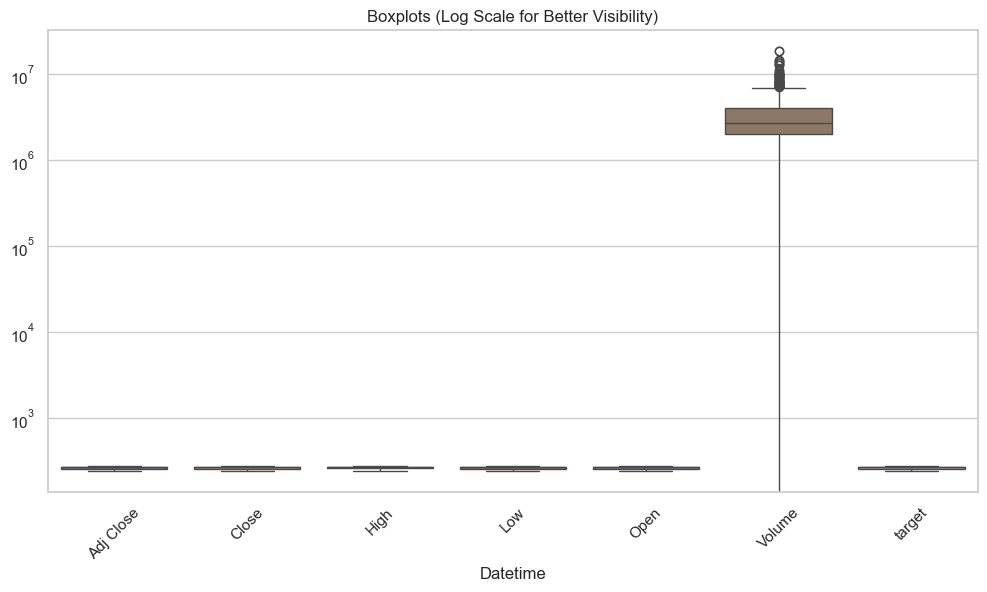

In [234]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_check, showfliers=True)
plt.yscale("log")  # Helps with Volume scale
plt.title("Boxplots (Log Scale for Better Visibility)")
plt.xticks(rotation=45)
plt.show()

# Create new relevant features

In [235]:
# Simple Returns
df["return_1h"] = df["Close"].pct_change()

# Lag features
df["close_lag1"] = df["Close"].shift(1)
df["close_lag2"] = df["Close"].shift(2)
df["close_lag3"] = df["Close"].shift(3)

# Log Returns
df["log_return_close"] = np.log(df["Close"] / df["Close"].shift(1))
df["log_return_open"] = np.log(df["Open"] / df["Open"].shift(1))

df[["Close", "return_1h", "log_return_close"]].head()

Datetime,Close,return_1h,log_return_close
2025-12-04 15:30:00+00:00,280.279999,NaN,NaN
2025-12-04 16:30:00+00:00,280.114990,-0.000589,-0.000589
2025-12-04 17:30:00+00:00,280.005005,-0.000393,-0.000393
2025-12-04 18:30:00+00:00,278.859985,-0.004089,-0.004098
2025-12-04 19:30:00+00:00,280.125000,0.004536,0.004526


In [236]:
# Candle Shape
df["hl_range"] = (df["High"] - df["Low"]) / df["Close"]
df["oc_change"] = (df["Close"] - df["Open"]) / df["Open"]

# Rolling statistics
df["ma_5"] = df["Close"].rolling(5).mean()
df["std_5"] = df["Close"].rolling(5).std()
df["var_5"] = df["Close"].rolling(5).var()

# Bollinger Bands
k = 2
df["bb_upper"] = df["ma_5"] + k * df["std_5"]
df["bb_lower"] = df["ma_5"] - k * df["std_5"]
df["bb_width"] = df["bb_upper"] - df["bb_lower"]

df[["ma_5", "std_5", "bb_upper", "bb_lower", "bb_width"]].tail()

Datetime,ma_5,std_5,bb_upper,bb_lower,bb_width
2026-03-03 16:30:00+00:00,263.110004,1.261368,265.632739,260.587268,5.045471
2026-03-03 17:30:00+00:00,262.544006,1.222632,264.989271,260.098742,4.890530
2026-03-03 18:30:00+00:00,262.355005,0.837837,264.030678,260.679331,3.351347
2026-03-03 19:30:00+00:00,262.559003,0.928224,264.415450,260.702556,3.712894
2026-03-03 20:30:00+00:00,262.787000,1.061972,264.910943,260.663056,4.247887


In [237]:
# Momentum (difference over n periods)
n = 5
df["momentum"] = df["Close"] - df["Close"].shift(n)

# Rolling max and min
df["rolling_max_5"] = df["Close"].rolling(n).max()
df["rolling_min_5"] = df["Close"].rolling(n).min()

# RSI (Relative Strength Index)
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
roll_up = gain.rolling(14).mean()
roll_down = loss.rolling(14).mean()
rs = roll_up / roll_down
df["RSI_14"] = 100 - (100 / (1 + rs))

df[["momentum", "rolling_max_5", "rolling_min_5", "RSI_14"]].tail()

Datetime,momentum,rolling_max_5,rolling_min_5,RSI_14
2026-03-03 16:30:00+00:00,-4.250000,264.600006,261.809998,29.189729
2026-03-03 17:30:00+00:00,-2.829987,264.600006,261.480011,32.792477
2026-03-03 18:30:00+00:00,-0.945007,263.654999,261.480011,43.057841
2026-03-03 19:30:00+00:00,1.019989,263.654999,261.480011,38.341377
2026-03-03 20:30:00+00:00,1.139984,263.709991,261.480011,48.140573


In [238]:
# SMA and EMA
df["SMA_10"] = df["Close"].rolling(10).mean()
df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

# Trend Slope (linear regression over window)
from scipy.stats import linregress

def slope(series):
    if len(series) < len(series.index):
        return np.nan
    x = np.arange(len(series))
    y = series.values
    return linregress(x, y).slope

df["slope_10"] = df["Close"].rolling(10).apply(slope, raw=False)

df[["SMA_10", "EMA_10", "slope_10"]].tail()

Datetime,SMA_10,EMA_10,slope_10
2026-03-03 16:30:00+00:00,264.128000,264.095199,-0.325332
2026-03-03 17:30:00+00:00,263.895001,263.619710,-0.490968
2026-03-03 18:30:00+00:00,263.824503,263.626126,-0.473060
2026-03-03 19:30:00+00:00,263.552502,263.563194,-0.357727
2026-03-03 20:30:00+00:00,263.373502,263.589884,-0.219304


# Display dataset with all new features

In [ ]:
df.tail()

Datetime,Adj Close,Close,High,Low,Open,Volume,target,return_1h,close_lag1,close_lag2,...,bb_upper,bb_lower,bb_width,momentum,rolling_max_5,rolling_min_5,RSI_14,SMA_10,EMA_10,slope_10
2026-03-03 16:30:00+00:00,261.809998,261.809998,263.779999,261.579987,262.480011,2940122,261.480011,-0.002895,262.570007,262.260010,...,265.632739,260.587268,5.045471,-4.250000,264.600006,261.809998,29.189729,264.128000,264.095199,-0.325332
2026-03-03 17:30:00+00:00,261.480011,261.480011,261.869995,260.130005,261.799988,2901307,263.654999,-0.001260,261.809998,262.570007,...,264.989271,260.098742,4.890530,-2.829987,264.600006,261.480011,32.792477,263.895001,263.619710,-0.490968
2026-03-03 18:30:00+00:00,263.654999,263.654999,263.910004,261.369995,261.440002,2917518,263.279999,0.008318,261.480011,261.809998,...,264.030678,260.679331,3.351347,-0.945007,263.654999,261.480011,43.057841,263.824503,263.626126,-0.473060
2026-03-03 19:30:00+00:00,263.279999,263.279999,264.614990,262.510010,263.670013,2571377,263.709991,-0.001422,263.654999,261.480011,...,264.415450,260.702556,3.712894,1.019989,263.654999,261.480011,38.341377,263.552502,263.563194,-0.357727
2026-03-03 20:30:00+00:00,263.709991,263.709991,263.959991,262.339996,263.239990,4136373,NaN,0.001633,263.279999,263.654999,...,264.910943,260.663056,4.247887,1.139984,263.709991,261.480011,48.140573,263.373502,263.589884,-0.219304


# Reassamble the dataset into daily data (downsampling) 

In [240]:
# Reassemble into daily data
daily_df = df.resample('D').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Adj Close': 'last',
    'Volume': 'sum'
}).dropna(subset=['Open'])

In [241]:
# Previous close
daily_df['Prev_Close'] = daily_df['Close'].shift(1)

# True Range components
high_low = daily_df['High'] - daily_df['Low']
high_pc = (daily_df['High'] - daily_df['Prev_Close']).abs()
low_pc = (daily_df['Low'] - daily_df['Prev_Close']).abs()

# True Range
daily_df['TR'] = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)

# Average True Range
daily_df['ATR_3'] = daily_df['TR'].rolling(window=3).mean()

daily_df.tail()

Datetime,Open,High,Low,Close,Adj Close,Volume,Prev_Close,TR,ATR_3
2026-02-25 00:00:00+00:00,271.679993,274.940002,271.049988,274.179993,274.179993,16849997,272.170013,3.890015,6.146332
2026-02-26 00:00:00+00:00,274.954987,276.109985,270.795013,272.989990,272.989990,15625247,274.179993,5.314972,5.901662
2026-02-27 00:00:00+00:00,272.809998,272.809998,262.890015,264.170013,264.170013,30527693,272.989990,10.099976,6.434987
2026-03-02 00:00:00+00:00,262.440002,266.529999,260.200012,264.600006,264.600006,24875050,264.170013,6.329987,7.248311
2026-03-03 00:00:00+00:00,263.480011,265.559998,260.130005,263.709991,263.709991,27531100,264.600006,5.429993,7.286652


In [242]:
# Drop NA after all features
df_ml = df.dropna().copy()

features = [
    "Close", "return_1h", "log_return_close", "log_return_open",
    "close_lag1", "close_lag2", "close_lag3",
    "hl_range", "oc_change",
    "ma_5", "std_5", "var_5",
    "bb_width",
    "momentum", "rolling_max_5", "rolling_min_5", "RSI_14",
    "SMA_10", "EMA_10", "slope_10"
]

X = df_ml[features]
y = df_ml["target"]

print(X.shape, y.shape)

(401, 20) (401,)
